# Monte Carlo Player Projection Engine
### Vectorised FPL Points Simulation across Remaining Fixtures

This notebook demonstrates the core simulation engine used in the production football analytics pipeline.

**What it does.** For every player, every remaining fixture, and N = 10,000 iterations it simultaneously:

1. Draws `Bernoulli(start_probability)` — does the player even feature?
2. Draws `Poisson(dc_lambda)` team goals from fixture-level Dixon-Coles attack parameters
3. Allocates individual goals/assists via `Binomial(team_goals, player_share)` — correctly modelling player output as *dependent on team output*
4. Computes FPL points using a position-specific scoring dispatch table (no conditional branching)
5. Sums across fixtures to a full remaining-season points distribution per player

All three dimensions — **players × fixtures × iterations** — live in a single `(n_players, n_fixtures, n_iterations)` tensor. No Python loops.

> **Data note:** Player rates and DC lambdas are synthetic but calibrated to realistic Premier League ranges. The architecture mirrors the production system exactly.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

np.random.seed(42)
pd.set_option("display.float_format", "{:.2f}".format)

N_ITER = 10_000
print(f"Engine initialised | {N_ITER:,} iterations per player-fixture pair")


Engine initialised | 10,000 iterations per player-fixture pair


## 1 — Fixture Schedule: Dixon-Coles Attack & Concede Lambdas

Each fixture is parameterised by two DC-derived values for each player's team:

| Parameter | Meaning |
|---|---|
| `attack_lam` | Expected goals *for* — player's team DC attack × opponent DC defence |
| `concede_lam` | Expected goals *against* — opponent DC attack × player's team DC defence |

In production, these are updated weekly via a rolling DC refit on the last 38+ matches,
down-weighting older fixtures with an exponential decay factor `exp(−ξ × match_age_weeks)`.


In [2]:
fixtures = pd.DataFrame({
    "gw":    [33,              34,             35,              36,                  37],
    "label": ["vs Arsenal (H)","vs Wolves (A)","vs Palace (H)","vs Bournemouth (H)","vs Chelsea (A)"],
})
N_FIX = len(fixtures)

# Shape: (n_players=6, n_fixtures=5)
# Players 0-1 share a strong-attack / leaky-defence team
# Players 2-3 share a balanced mid-table team
# Players 4-5 share a defensively solid, lower-scoring team

attack_lam = np.array([
    [1.9, 1.2, 1.8, 1.6, 0.8],   # FWD  — strong attacking team
    [1.9, 1.2, 1.8, 1.6, 0.8],   # MID  — same team
    [1.3, 1.1, 1.4, 1.5, 0.9],   # DEF  — balanced team
    [1.3, 1.1, 1.4, 1.5, 0.9],   # MID  — same team
    [0.8, 1.0, 0.9, 1.1, 0.7],   # GK   — defensive team
    [0.8, 1.0, 0.9, 1.1, 0.7],   # MID  — same team
])

concede_lam = np.array([
    [1.8, 1.0, 0.9, 0.7, 1.6],   # FWD's team — tough run-in
    [1.8, 1.0, 0.9, 0.7, 1.6],
    [1.2, 0.8, 0.9, 1.0, 1.3],   # DEF's team — moderate
    [1.2, 0.8, 0.9, 1.0, 1.3],
    [0.7, 0.9, 0.7, 0.8, 1.1],   # GK's team  — very solid
    [0.7, 0.9, 0.7, 0.8, 1.1],
])

print("Remaining fixtures:")
print(fixtures.to_string(index=False))
print(f"\nattack_lam range : {attack_lam.min():.1f} – {attack_lam.max():.1f}")
print(f"concede_lam range: {concede_lam.min():.1f} – {concede_lam.max():.1f}")


Remaining fixtures:
 gw              label
 33     vs Arsenal (H)
 34      vs Wolves (A)
 35      vs Palace (H)
 36 vs Bournemouth (H)
 37     vs Chelsea (A)

attack_lam range : 0.7 – 1.9
concede_lam range: 0.7 – 1.8


## 2 — Player Roster & FPL Scoring Dispatch Table

### Roster parameters

| Field | Description |
|---|---|
| `start_prob` | Bernoulli probability of starting — encodes injury/rotation/suspension risk |
| `goal_share` | Fraction of team goals attributed to this player (calibrated from 5-GW per-90 rolling average) |
| `assist_share` | Same for assists |

### FPL points dispatch (position-specific)

| Event | GK | DEF | MID | FWD |
|---|---|---|---|---|
| Goal scored | 6 | 6 | **5** | **4** |
| Assist | 3 | 3 | 3 | 3 |
| Clean sheet (90 min) | **4** | **4** | 1 | 0 |
| Appearance (60+ min) | 2 | 2 | 2 | 2 |

The dispatch is implemented as a `(n_players, 1, 1)` NumPy broadcast — no `if/elif` branching.


In [3]:
roster = pd.DataFrame({
    "name":         ["Elite Striker",    "Creative Midfielder", "Reliable Defender",
                     "Set-Piece Mid",    "Elite GK",           "Pacey Winger"],
    "pos":          ["FWD",              "MID",                "DEF",
                     "MID",             "GK",                 "MID"],
    "start_prob":   [0.95,              0.90,                 0.85,
                     0.75,             0.99,                 0.70],
    "goal_share":   [0.25,              0.10,                 0.04,
                     0.08,             0.00,                 0.12],
    "assist_share": [0.08,              0.18,                 0.05,
                     0.14,             0.00,                 0.15],
})
N_PLAY = len(roster)

# FPL scoring tables — vectorised as (n_players, 1, 1) arrays
GOAL_PTS   = {"GK": 6, "DEF": 6, "MID": 5, "FWD": 4}
CS_PTS     = {"GK": 4, "DEF": 4, "MID": 1, "FWD": 0}
ASSIST_PTS = 3
APP_PTS    = 2   # 60+ min appearance bonus (simplified: all starters get it)

goal_pts_v = np.array([GOAL_PTS[p] for p in roster["pos"]]).reshape(N_PLAY, 1, 1)
cs_pts_v   = np.array([CS_PTS[p]   for p in roster["pos"]]).reshape(N_PLAY, 1, 1)

print(roster.to_string(index=False))
print(f"\nGoal points vector   : {goal_pts_v.ravel()}")
print(f"Clean sheet pts vec  : {cs_pts_v.ravel()}")


               name pos  start_prob  goal_share  assist_share
      Elite Striker FWD        0.95        0.25          0.08
Creative Midfielder MID        0.90        0.10          0.18
  Reliable Defender DEF        0.85        0.04          0.05
      Set-Piece Mid MID        0.75        0.08          0.14
           Elite GK  GK        0.99        0.00          0.00
       Pacey Winger MID        0.70        0.12          0.15

Goal points vector   : [4 5 6 5 6 5]
Clean sheet pts vec  : [0 1 4 1 4 1]


## 3 — The Vectorised Simulation Engine

```
tensor shape: (6 players, 5 fixtures, 10,000 iterations) = 300,000 simultaneous simulations
```

**Step A — Bernoulli availability mask** `(N_PLAY, N_FIX, N_ITER)` binary

**Step B — Poisson team goals** from fixture-level DC lambdas — one `np.random.poisson` call,
no loops; `lam` shape `(N_PLAY, N_FIX, 1)` broadcasts across the iteration axis

**Step C — Binomial thinning** allocates team goals to individual players.
Why Binomial and not an independent Poisson per player?
Because player goals are *not* independent of each other — if a team scores 0 goals,
no player can score. `Binomial(n=team_goals, p=goal_share)` respects this dependency.

**Step D — Clean sheet** from opponent Poisson draw — `(team_concede == 0)`

**Step E — Points aggregation** — single broadcast multiply; the played mask zeroes
absent players with no branching

**Step F — Sum across fixtures** — `axis=1` collapse yields `(N_PLAY, N_ITER)`
remaining-season distribution


In [4]:
# ── A: Bernoulli availability mask ────────────────────────────────────────────
played = np.random.binomial(
    n=1,
    p=roster["start_prob"].values.reshape(N_PLAY, 1, 1),
    size=(N_PLAY, N_FIX, N_ITER),
)

# ── B: Poisson team goals from DC lambdas ────────────────────────────────────
team_goals   = np.random.poisson(lam=attack_lam.reshape(N_PLAY, N_FIX, 1),
                                  size=(N_PLAY, N_FIX, N_ITER))
team_concede = np.random.poisson(lam=concede_lam.reshape(N_PLAY, N_FIX, 1),
                                  size=(N_PLAY, N_FIX, N_ITER))

# ── C: Binomial thinning — individual player goals & assists ─────────────────
player_goals   = np.random.binomial(n=team_goals,
                                     p=roster["goal_share"].values.reshape(N_PLAY, 1, 1))
player_assists = np.random.binomial(n=team_goals,
                                     p=roster["assist_share"].values.reshape(N_PLAY, 1, 1))

# ── D: Clean sheet flag ───────────────────────────────────────────────────────
cs_flag = (team_concede == 0).astype(np.int8)

# ── E: FPL points per player × fixture × iteration ───────────────────────────
pts_grid = (
    player_goals   * goal_pts_v   +
    player_assists * ASSIST_PTS   +
    cs_flag        * cs_pts_v     +
    APP_PTS
) * played   # zeros out absent players — no branching

# ── F: Sum across fixtures → remaining-season distribution ───────────────────
pts_remaining = pts_grid.sum(axis=1)   # shape: (N_PLAY, N_ITER)

print(f"Tensor shape (players × fixtures × iterations): {pts_grid.shape}")
print(f"Memory footprint : {pts_grid.nbytes / 1e6:.1f} MB  |  dtype: {pts_grid.dtype}")
print(f"Output shape     : {pts_remaining.shape}")


Tensor shape (players × fixtures × iterations): (6, 5, 10000)
Memory footprint : 2.4 MB  |  dtype: int64
Output shape     : (6, 10000)


## 4 — Results

`P10` is the pessimistic floor — this player will beat this score in 90% of simulations.
`P90` is the optimistic ceiling — beaten only 10% of the time.
`P(blank GW)` is the probability the player returns only appearance points or fewer in a given gameweek.


In [5]:
p10 = np.percentile(pts_remaining, 10, axis=1)
p50 = np.percentile(pts_remaining, 50, axis=1)
p90 = np.percentile(pts_remaining, 90, axis=1)

# Per-GW blank rate: max pts in that fixture <= APP_PTS
blank_rate = (pts_grid.max(axis=2) <= APP_PTS).mean(axis=1)

summary = pd.DataFrame({
    "Player":        roster["name"],
    "Pos":           roster["pos"],
    "Exp Pts":       pts_remaining.mean(axis=1).round(1),
    "P10 (floor)":   p10.round(1),
    "P50 (median)":  p50.round(1),
    "P90 (ceiling)": p90.round(1),
    "P(Blank GW)":   blank_rate.round(3),
}).sort_values("Exp Pts", ascending=False).reset_index(drop=True)

print("Expected FPL Points — Remaining 5 Fixtures")
print("=" * 65)
print(summary.to_string(index=False))


Expected FPL Points — Remaining 5 Fixtures
             Player Pos  Exp Pts  P10 (floor)  P50 (median)  P90 (ceiling)  P(Blank GW)
           Elite GK  GK    18.60        14.00         18.00          26.00         0.00
      Elite Striker FWD    18.10        10.00         18.00          26.00         0.00
Creative Midfielder MID    17.40        10.00         17.00          26.00         0.00
  Reliable Defender DEF    16.70        10.00         16.00          24.00         0.00
      Set-Piece Mid MID    12.70         7.00         12.00          20.00         0.00
       Pacey Winger MID    11.80         6.00         11.00          19.00         0.00


## 5 — Visualisations

- **Chart A (top):** Per-player expected points with P10–P90 uncertainty band — colours by position
- **Chart B (bottom-left):** Full probability distributions overlaid — dashed vertical = mean
- **Chart C (bottom-right):** Fixture-by-fixture expected points heatmap — shows which GWs drive returns


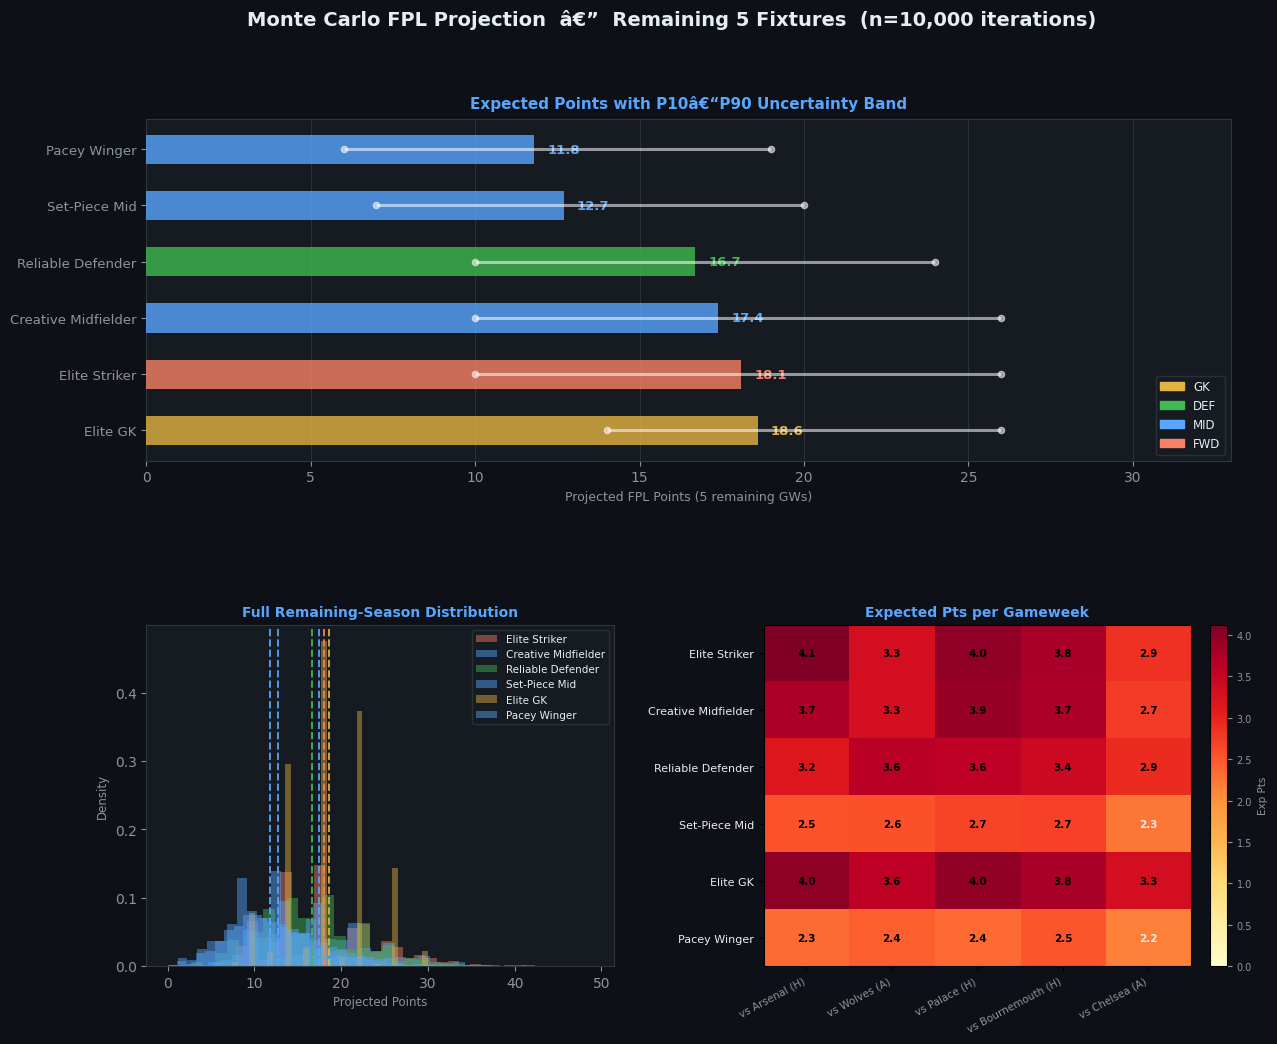

Saved → assets/mc_projection_output.png


In [6]:
BG, PANEL  = "#0D1117", "#161B22"
ACCENT, TEXT, DIM = "#58A6FF", "#E6EDF3", "#8B949E"
POS_COL = {"GK": "#E3B341", "DEF": "#3FB950", "MID": "#58A6FF", "FWD": "#F78166"}

ordered = summary["Player"].tolist()
means   = summary["Exp Pts"].values
lowers  = summary["P10 (floor)"].values
uppers  = summary["P90 (ceiling)"].values
cols    = [POS_COL[roster.set_index("name").loc[n, "pos"]] for n in ordered]

fig = plt.figure(figsize=(14, 11), facecolor=BG)
fig.suptitle(
    f"Monte Carlo FPL Projection  —  Remaining {N_FIX} Fixtures  (n={N_ITER:,} iterations)",
    color=TEXT, fontsize=14, fontweight="bold", y=0.98,
)
gs = GridSpec(2, 2, figure=fig, hspace=0.48, wspace=0.32)

# ── A: Expected Points Range ─────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :])
ax1.set_facecolor(PANEL)
for sp in ax1.spines.values():
    sp.set_edgecolor("#30363D")

y   = range(len(ordered))
ax1.barh(y, means, color=cols, alpha=0.80, height=0.52, zorder=3)
ax1.hlines(y, lowers, uppers, color="white", linewidth=2.2, alpha=0.55, zorder=4)
ax1.plot(lowers, y, "o", color="white", markersize=4.5, alpha=0.55, zorder=5)
ax1.plot(uppers, y, "o", color="white", markersize=4.5, alpha=0.55, zorder=5)

for i, (m, name) in enumerate(zip(means, ordered)):
    ax1.text(m + 0.4, i, f"{m:.1f}", va="center", color=cols[i],
             fontsize=9.5, fontweight="bold")

ax1.set_yticks(y)
ax1.set_yticklabels(ordered, color=TEXT, fontsize=9.5)
ax1.set_xlabel("Projected FPL Points (5 remaining GWs)", color=DIM, fontsize=9)
ax1.set_title("Expected Points with P10–P90 Uncertainty Band", color=ACCENT,
              fontsize=11, fontweight="bold", pad=8)
ax1.tick_params(colors=DIM)
ax1.grid(axis="x", color="#30363D", linewidth=0.6, zorder=1)
ax1.set_xlim(0, uppers.max() + 7)

legend_patches = [mpatches.Patch(color=c, label=p) for p, c in POS_COL.items()]
ax1.legend(handles=legend_patches, loc="lower right",
           facecolor=PANEL, edgecolor="#30363D", labelcolor=TEXT, fontsize=8.5)

# ── B: Distribution Overlay ───────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
ax2.set_facecolor(PANEL)
for sp in ax2.spines.values():
    sp.set_edgecolor("#30363D")

for i, row in roster.iterrows():
    col = POS_COL[row["pos"]]
    ax2.hist(pts_remaining[i], bins=35, density=True, alpha=0.45,
             color=col, edgecolor="none", label=row["name"])
    ax2.axvline(pts_remaining[i].mean(), color=col, linewidth=1.4,
                linestyle="--", alpha=0.9)

ax2.set_title("Full Remaining-Season Distribution", color=ACCENT,
              fontsize=10, fontweight="bold", pad=6)
ax2.set_xlabel("Projected Points", color=DIM, fontsize=8.5)
ax2.set_ylabel("Density", color=DIM, fontsize=8.5)
ax2.tick_params(colors=DIM)
ax2.legend(facecolor=PANEL, edgecolor="#30363D", labelcolor=TEXT,
           fontsize=7.5, loc="upper right")

# ── C: Fixture-by-Fixture Heatmap ─────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
ax3.set_facecolor(PANEL)

fix_means = pts_grid.mean(axis=2)   # (N_PLAY, N_FIX)
im = ax3.imshow(fix_means, cmap="YlOrRd", aspect="auto", vmin=0)
ax3.set_xticks(range(N_FIX))
ax3.set_xticklabels(fixtures["label"], rotation=28, ha="right",
                    color=DIM, fontsize=7.5)
ax3.set_yticks(range(N_PLAY))
ax3.set_yticklabels(roster["name"], color=TEXT, fontsize=8)
ax3.set_title("Expected Pts per Gameweek", color=ACCENT,
              fontsize=10, fontweight="bold", pad=6)

thresh = fix_means.max() * 0.55
for i in range(N_PLAY):
    for j in range(N_FIX):
        ax3.text(j, i, f"{fix_means[i, j]:.1f}", ha="center", va="center",
                 color="black" if fix_means[i, j] > thresh else TEXT,
                 fontsize=7.5, fontweight="bold")

cbar = fig.colorbar(im, ax=ax3, fraction=0.046, pad=0.04)
cbar.ax.tick_params(colors=DIM, labelsize=7)
cbar.set_label("Exp Pts", color=DIM, fontsize=7.5)

plt.savefig("assets/mc_projection_output.png", dpi=150, bbox_inches="tight",
            facecolor=BG, pad_inches=0.2)
plt.show()
print("Saved → assets/mc_projection_output.png")


## Connection to the Production System

This notebook is a runnable, self-contained version of the engine described in the project README.

| This notebook | Production system |
|---|---|
| 6 synthetic players | 378 active Premier League players |
| 5 remaining fixtures | Dynamic — updates weekly as fixtures settle |
| Pre-set DC lambdas | Refitted weekly: rolling DC on last 38+ matches, exponential decay |
| Fixed `start_prob` | Updated from FPL ownership, injury API, and press-conference signals |
| 10,000 iterations | 10,000 — sufficient for stable percentiles at this player count |
| Fixed `goal_share` | Calibrated from rolling 5-GW per-90 EWMA |

**Why Binomial thinning, not independent Poisson per player?**
A naive approach gives each player their own independent Poisson draw. This is wrong: it lets
player A and player B both score even when the team Poisson draw gives 0 goals — an impossibility.
`Binomial(n=team_goals, p=goal_share)` correctly propagates the team-level constraint down to individual players.

**Why the 3-D tensor?**
Adding 50 more players or 3 more fixtures costs one reshape operation, not additional loop iterations.
At 378 players × 8 remaining fixtures × 10,000 iterations = 30.2 million cells, the vectorised approach
completes in under two seconds on a standard laptop CPU.
